# 01 — Exploratory Data Analysis (OULAD Recommender Project)

This notebook documents the exploratory data analysis and preprocessing rationale
for the personalised educational content recommendation system built using OULAD.

## Objectives

This notebook is used to:

- inspect the processed interaction and item datasets
- quantify user and item sparsity
- analyse interaction strength and activity-type distributions
- justify aggregation and feature engineering choices
- generate figures that can be reused in the final report

In [17]:

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

INTERACTIONS_PATH = "../data/processed/interactions_agg.csv"
ITEMS_PATH = "../data/processed/items_final.csv"
FIGURES_DIR = "../figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

interactions = pd.read_csv(INTERACTIONS_PATH)
items = pd.read_csv(ITEMS_PATH)

interactions["user_id"] = interactions["user_id"].astype(str)
interactions["item_id"] = interactions["item_id"].astype(str)
items["item_id"] = items["item_id"].astype(str)

print("Interactions shape:", interactions.shape)
print("Items shape:", items.shape)

Interactions shape: (1957344, 13)
Items shape: (5690, 24)


In [18]:

interactions.head(10)

,user_id,item_id,strength,interaction_count,first_date,last_date,mean_date,activity_type,code_module,code_presentation,strength_log,engagement_score,rating
0,100064,FFF_2013J_716216,272,112,-2,259,99.303571,forumng,FFF,2013J,5.609472,6.791319,3.448
1,100064,FFF_2013J_716217,51,19,39,191,81.421053,forumng,FFF,2013J,3.951244,4.700177,2.584
2,100064,FFF_2013J_716219,78,30,0,266,122.366667,forumng,FFF,2013J,4.369448,5.227945,2.802
3,100064,FFF_2013J_716222,89,27,-13,213,80.296296,forumng,FFF,2013J,4.499810,5.332861,2.845
4,100064,FFF_2013J_716237,6,5,203,234,217.000000,folder,FFF,2013J,1.945910,2.393850,1.631
5,100064,FFF_2013J_716238,793,170,-14,266,119.411765,homepage,FFF,2013J,6.677083,7.962499,3.931
6,100064,FFF_2013J_716239,74,7,38,145,67.142857,oucontent,FFF,2013J,4.317488,4.837348,2.640
7,100064,FFF_2013J_716240,1,1,4,4,4.000000,oucontent,FFF,2013J,0.693147,0.866434,1.000
8,100064,FFF_2013J_716241,7,1,181,181,181.000000,oucontent,FFF,2013J,2.079442,2.252728,1.573
9,100064,FFF_2013J_716243,1,1,196,196,196.000000,oucontent,FFF,2013J,0.693147,0.866434,1.000


In [35]:
display_cols = [
    c for c in [
        "item_id",
        "activity_type",
        "code_module",
        "code_presentation",
        "week_from",
        "week_to",
        "module_presentation_length",
        "popularity_band"
    ] if c in items.columns
]

items_preview = items[display_cols].copy()

for col in ["week_from", "week_to"]:
    if col in items_preview.columns:
        items_preview[col] = items_preview[col].fillna("missing")

items_preview.head(10)

,item_id,activity_type,code_module,code_presentation,week_from,week_to,module_presentation_length,popularity_band
0,AAA_2013J_546943,resource,AAA,2013J,missing,missing,268,niche
1,AAA_2013J_546712,oucontent,AAA,2013J,missing,missing,268,popular
2,AAA_2013J_546888,url,AAA,2013J,missing,missing,268,niche
3,AAA_2013J_547035,resource,AAA,2013J,missing,missing,268,niche
4,AAA_2013J_546614,homepage,AAA,2013J,missing,missing,268,very_popular
5,AAA_2013J_546678,oucontent,AAA,2013J,missing,missing,268,popular
6,AAA_2013J_546708,oucontent,AAA,2013J,missing,missing,268,moderate_popularity
7,AAA_2013J_546995,resource,AAA,2013J,missing,missing,268,niche
8,AAA_2013J_546884,url,AAA,2013J,missing,missing,268,niche
9,AAA_2013J_546675,oucontent,AAA,2013J,missing,missing,268,popular


## Basic dataset summary

In [20]:

summary = {
    "n_interactions": int(len(interactions)),
    "n_users": int(interactions["user_id"].nunique()),
    "n_items": int(interactions["item_id"].nunique()),
    "avg_interactions_per_user": float(len(interactions) / interactions["user_id"].nunique()),
    "avg_interactions_per_item": float(len(interactions) / interactions["item_id"].nunique()),
    "mean_strength": float(interactions["strength"].mean()),
    "mean_rating": float(interactions["rating"].mean()),
}
summary

{'n_interactions': 1957344,
 'n_users': 25344,
 'n_items': 5690,
 'avg_interactions_per_user': 77.23106060606061,
 'avg_interactions_per_item': 343.9971880492091,
 'mean_strength': 19.58534881962496,
 'mean_rating': 1.519071307853908}

## Missing values

In [21]:

missing_interactions = interactions.isna().sum().sort_values(ascending=False)
missing_items = items.isna().sum().sort_values(ascending=False)

print("Missing values — interactions")
display(missing_interactions[missing_interactions > 0])

print("\nMissing values — items")
display(missing_items[missing_items > 0])

Missing values — interactions


Series([], dtype: int64)


Missing values — items


week_from    4589
week_to      4589
dtype: int64

## User and item sparsity

In [22]:

user_counts = interactions["user_id"].value_counts()
item_counts = interactions["item_id"].value_counts()

print(user_counts.describe())
print()
print(item_counts.describe())

count    25344.000000
mean        77.231061
std         61.528596
min          5.000000
25%         33.000000
50%         58.000000
75%        106.000000
max        577.000000
Name: count, dtype: float64

count    5690.000000
mean      343.997188
std       391.129667
min         5.000000
25%        51.000000
50%       190.500000
75%       510.000000
max      2255.000000
Name: count, dtype: float64


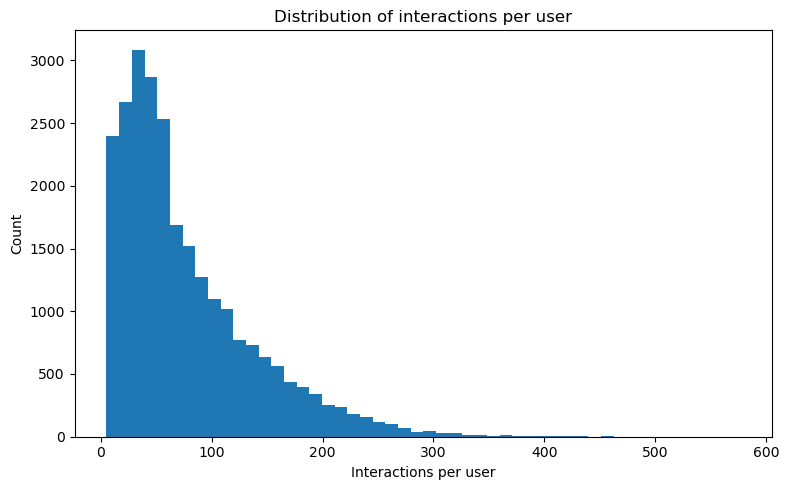

In [23]:

plt.figure()
plt.hist(user_counts, bins=50)
plt.xlabel("Interactions per user")
plt.ylabel("Count")
plt.title("Distribution of interactions per user")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_user_interactions_hist.png"), dpi=200)
plt.show()

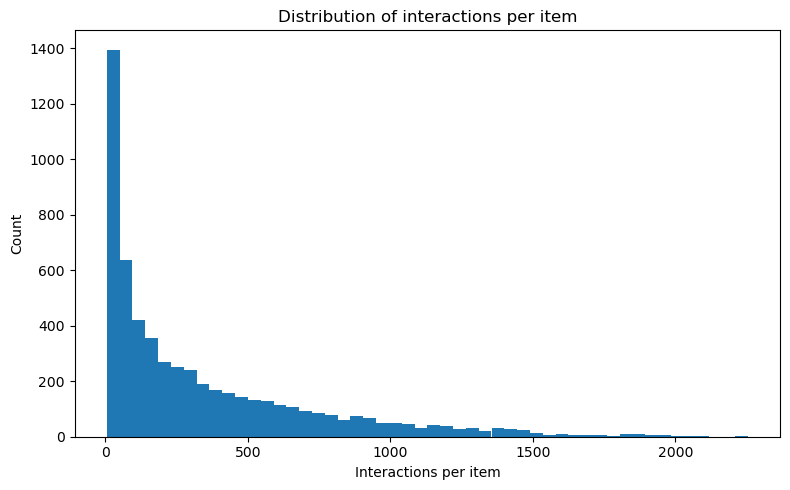

In [24]:

plt.figure()
plt.hist(item_counts, bins=50)
plt.xlabel("Interactions per item")
plt.ylabel("Count")
plt.title("Distribution of interactions per item")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_item_interactions_hist.png"), dpi=200)
plt.show()

## Activity type distribution

In [25]:

activity_counts = interactions["activity_type"].value_counts().sort_values(ascending=False)
activity_counts

activity_type
oucontent        507333
resource         468988
subpage          456577
url              155557
forumng          101471
quiz              99042
page              30716
homepage          28464
ouwiki            25281
questionnaire     20026
externalquiz      17355
oucollaborate     16944
dualpane           7604
glossary           6352
dataplus           5933
ouelluminate       4165
htmlactivity       3474
folder             1934
sharedsubpage       128
Name: count, dtype: int64

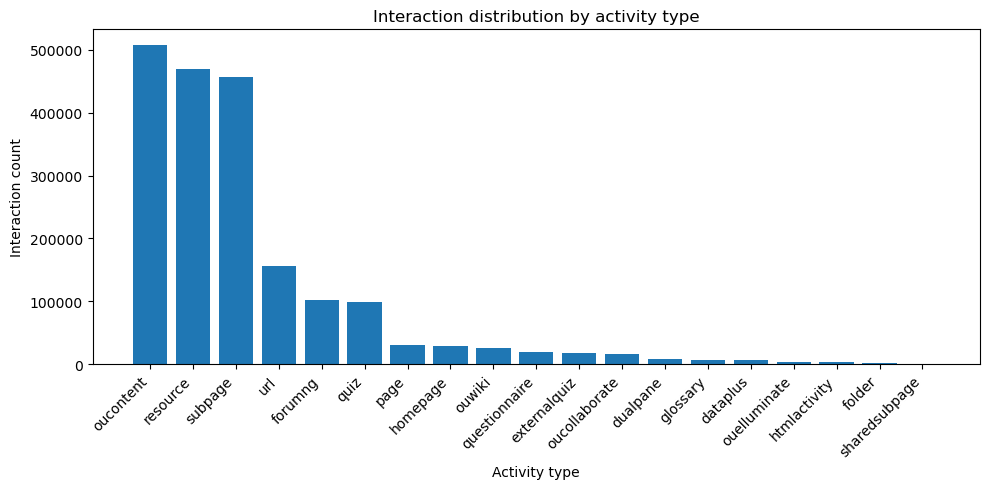

In [26]:

plt.figure(figsize=(10, 5))
plt.bar(activity_counts.index.astype(str), activity_counts.values)
plt.xlabel("Activity type")
plt.ylabel("Interaction count")
plt.title("Interaction distribution by activity type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_activity_type_distribution.png"), dpi=200)
plt.show()

## Module distribution

In [27]:

module_counts = interactions["code_module"].value_counts().sort_values(ascending=False)
module_counts

code_module
FFF    758162
DDD    491045
BBB    276696
CCC    196150
EEE    114546
GGG     76583
AAA     44162
Name: count, dtype: int64

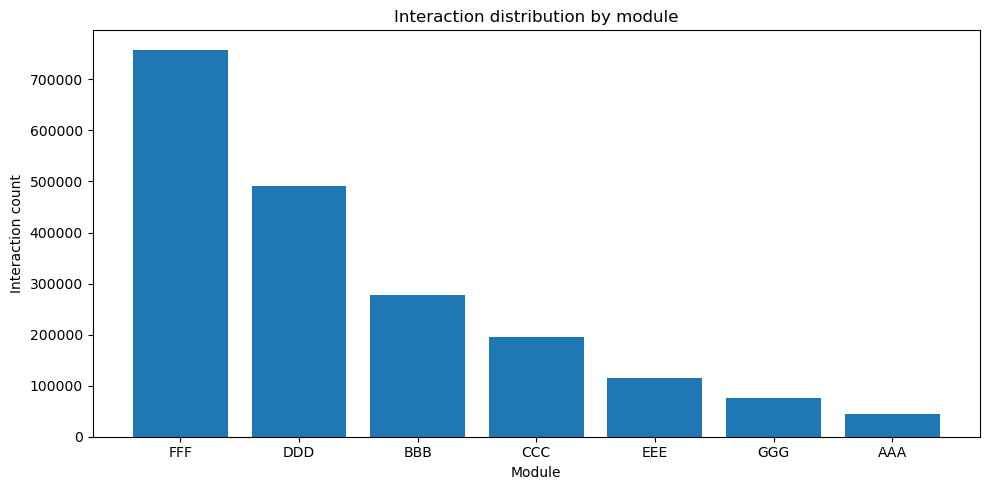

In [28]:

plt.figure(figsize=(10, 5))
plt.bar(module_counts.index.astype(str), module_counts.values)
plt.xlabel("Module")
plt.ylabel("Interaction count")
plt.title("Interaction distribution by module")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_module_distribution.png"), dpi=200)
plt.show()

## Strength and rating distributions

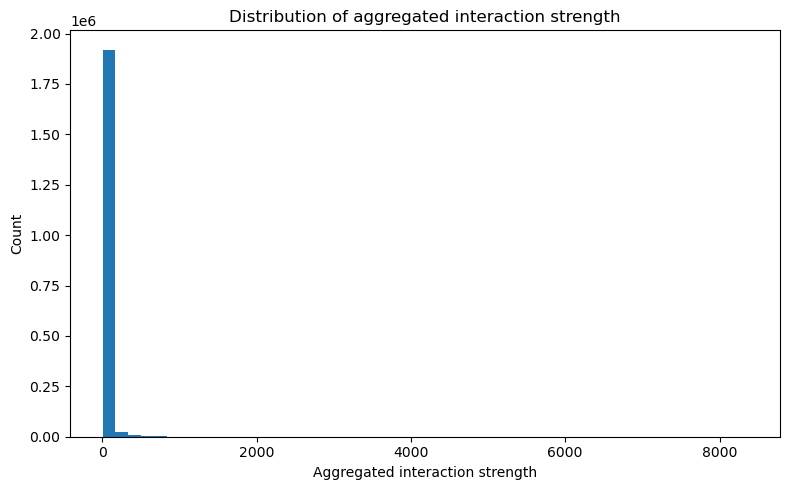

In [29]:

plt.figure()
plt.hist(interactions["strength"], bins=50)
plt.xlabel("Aggregated interaction strength")
plt.ylabel("Count")
plt.title("Distribution of aggregated interaction strength")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_strength_distribution.png"), dpi=200)
plt.show()

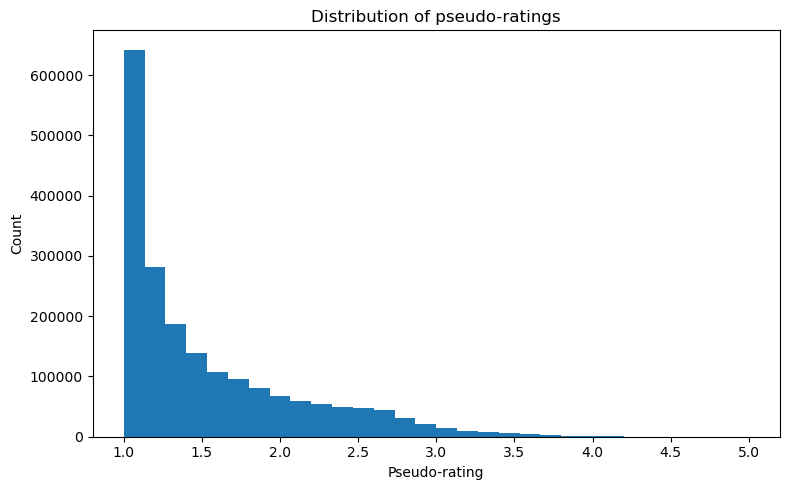

In [30]:

plt.figure()
plt.hist(interactions["rating"], bins=30)
plt.xlabel("Pseudo-rating")
plt.ylabel("Count")
plt.title("Distribution of pseudo-ratings")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_rating_distribution.png"), dpi=200)
plt.show()

## Note on missing week metadata

Some OULAD learning resources do not contain valid `week_from` or `week_to` values in the source metadata.  
For this reason:

- the original numeric columns may display `NaN`
- the engineered categorical buckets intentionally map missing week values to `unknown_week`

This is expected and reflects explicit handling of incomplete metadata rather than a preprocessing error.

## Engineered feature inspection

In [37]:
engineered_cols = [
    c for c in [
        "week_from_bucket",
        "week_to_bucket",
        "presentation_length_bucket",
        "resource_family",
        "popularity_band",
        "item_strength_log",
        "item_event_log",
        "text"
    ] if c in items.columns
]
items[["item_id"] + engineered_cols].head(10)

,item_id,week_from_bucket,week_to_bucket,presentation_length_bucket,resource_family,popularity_band,item_strength_log,item_event_log,text
0,AAA_2013J_546943,unknown_week,unknown_week,long_presentation,resource_AAA,niche,3.610918,3.433987,title Resource Resource description Educationa...
1,AAA_2013J_546712,unknown_week,unknown_week,long_presentation,oucontent_AAA,popular,6.269096,5.062595,title Oucontent Resource description Education...
2,AAA_2013J_546888,unknown_week,unknown_week,long_presentation,url_AAA,niche,2.772589,2.564949,title Url Resource description Educational res...
3,AAA_2013J_547035,unknown_week,unknown_week,long_presentation,resource_AAA,niche,3.367296,3.178054,title Resource Resource description Educationa...
4,AAA_2013J_546614,unknown_week,unknown_week,long_presentation,homepage_AAA,very_popular,11.851866,10.417209,title Homepage Resource description Educationa...
5,AAA_2013J_546678,unknown_week,unknown_week,long_presentation,oucontent_AAA,popular,7.665753,6.309918,title Oucontent Resource description Education...
6,AAA_2013J_546708,unknown_week,unknown_week,long_presentation,oucontent_AAA,moderate_popularity,4.574711,3.258097,title Oucontent Resource description Education...
7,AAA_2013J_546995,unknown_week,unknown_week,long_presentation,resource_AAA,niche,2.397895,2.397895,title Resource Resource description Educationa...
8,AAA_2013J_546884,unknown_week,unknown_week,long_presentation,url_AAA,niche,3.367296,3.218876,title Url Resource description Educational res...
9,AAA_2013J_546675,unknown_week,unknown_week,long_presentation,oucontent_AAA,popular,7.600902,6.220590,title Oucontent Resource description Education...


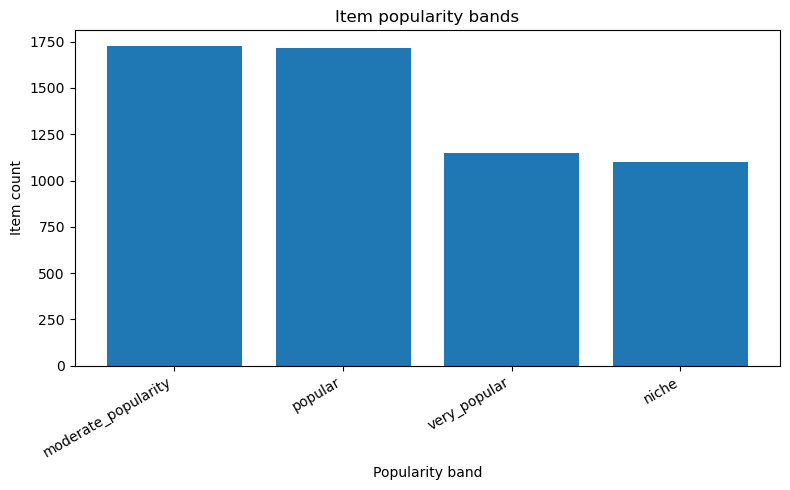

In [32]:

if "popularity_band" in items.columns:
    pop_band_counts = items["popularity_band"].value_counts()
    plt.figure()
    plt.bar(pop_band_counts.index.astype(str), pop_band_counts.values)
    plt.xlabel("Popularity band")
    plt.ylabel("Item count")
    plt.title("Item popularity bands")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "eda_popularity_band_distribution.png"), dpi=200)
    plt.show()

## Key EDA observations

Fill in / adapt these points when writing the report:

- The original OULAD interaction logs contain repeated user-item events, so aggregation is necessary.
- Interaction behaviour is sparse and long-tailed across both users and items.
- Activity types and modules are imbalanced, which helps explain why pure popularity is weak.
- Pseudo-ratings derived from engagement provide a usable learning signal for matrix factorisation, but they remain weaker than strong metadata-based signals.
- Richer item features improve the usefulness of the content-based and hybrid recommenders.